# NBA Game Outcome Prediction: Data Preparation

this notebook turns the two raw CSVs into a clean modeling table with one row per game, run exploratory analysis, and save everything the modeling notebook needs.

steps: load, filter to the 2015-16 season onward, build the target label, engineer pre-game features, explore the data, save modeling_table.csv.

## setup

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.dpi': 120, 'savefig.bbox': 'tight'})
C_HOME, C_AWAY = '#2E5C8A', '#C4553B'
os.makedirs('figs', exist_ok=True)
pd.set_option('display.max_columns', None)

## raw data

In [2]:
games = pd.read_csv('Games.csv', low_memory=False)
team  = pd.read_csv('TeamStatistics.csv', low_memory=False)

games['gameDate'] = pd.to_datetime(games['gameDate'])
team['gameDate']  = pd.to_datetime(team['gameDate'])

print('Games:', games.shape)
print('TeamStatistics:', team.shape)
games[['gameId','gameDate','hometeamName','awayteamName','homeScore','awayScore','winner','gameType']].head()

Games: (73279, 23)
TeamStatistics: (146560, 59)


,gameId,gameDate,hometeamName,awayteamName,homeScore,awayScore,winner,gameType
0,42500405,2026-06-13 20:30:00,Spurs,Knicks,90,94,1610612752,Playoffs
1,42500404,2026-06-10 20:30:00,Knicks,Spurs,107,106,1610612752,Playoffs
2,42500403,2026-06-08 20:30:00,Knicks,Spurs,111,115,1610612759,Playoffs
3,42500402,2026-06-05 20:30:00,Spurs,Knicks,104,105,1610612752,Playoffs
4,42500401,2026-06-03 20:30:00,Spurs,Knicks,95,105,1610612752,Playoffs


## data scope: 2015-16 season onward, competitive games only

the NBA season runs across two calendar years (October to June), so I cut at October 1, 2015. That date falls in the offseason gap, so it grabs the complete
2015-16 season onward without chopping any season in half.

I also kept only Regular Season and Playoff games.

In [3]:
SEASON_START = '2015-10-01'   # start of the 2015-16 season

game_mask = (games['gameDate'] >= SEASON_START) & (games['gameType'].isin(['Regular Season','Playoffs']))
games = games[game_mask].copy()
team  = team[team['gameId'].isin(games['gameId'])].copy()

# a few rows are missing core box score values, so drop them
core_cols = ['teamScore','opponentScore','fieldGoalsPercentage','reboundsTotal','assists','turnovers','win']
team = team.dropna(subset=core_cols).copy()

print('Games after filter:', len(games))
print('Team-stat rows after filter:', len(team))
print('Date range:', games['gameDate'].min().date(), 'to', games['gameDate'].max().date())

Games after filter: 14058
Team-stat rows after filter: 28116
Date range: 2015-10-27 to 2026-06-13


## target label

The label is home_win = 1 if the home team won, otherwise 0. The winner column already holds the winning team's ID, so I just compare it to the home team's ID.

Every game has a home team and an away team, so this covers every outcome: a 0 is the same thing as an away team win.

In [4]:
games['home_win'] = (games['winner'] == games['hometeamId']).astype(int)
print('Home win rate (naive baseline):', round(games['home_win'].mean(), 4))

Home win rate (naive baseline): 0.5658


## feature engineering

For each team I computed rolling averages over their last 5 and last 10 games for the key box score stats, plus rest days.

every rolling feature uses `.shift(1)` so a team's stats going into a game never include that game's own result. 

In [5]:
team = team.sort_values(['teamId','gameDate']).reset_index(drop=True)
team['pt_diff'] = team['teamScore'] - team['opponentScore']

stat_map = {
    'teamScore':'pts', 'opponentScore':'pts_allowed',
    'fieldGoalsPercentage':'fg_pct', 'threePointersPercentage':'fg3_pct',
    'reboundsTotal':'reb', 'assists':'ast', 'turnovers':'tov', 'win':'win',
    'pt_diff':'ptdiff'
}

def add_rolling(df, src, name, windows=(5, 10)):
    for w in windows:
        # shift(1) drops the current game, which is what prevents leakage
        df[f'{name}_r{w}'] = (df.groupby('teamId')[src]
                                .transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean()))
    return df

for src, name in stat_map.items():
    team = add_rolling(team, src, name)

team['rest_days'] = team.groupby('teamId')['gameDate'].diff().dt.days

feat_cols = [col for col in team.columns if col.endswith(('_r5','_r10'))] + ['rest_days']
print('Per-team features built:', len(feat_cols))

Per-team features built: 19


### home-side and away-side form to each game

Each game has two teams, so I split the per-team rows by the `home` flag and merge both sides back onto each game. That way the model sees the whole matchup instead of just one team.

In [6]:
keep = ['gameId','teamId','home'] + feat_cols
tf = team[keep].copy()

home_feats = (tf[tf['home'] == 1].drop(columns='home')
              .add_prefix('home_').rename(columns={'home_gameId':'gameId'}))
away_feats = (tf[tf['home'] == 0].drop(columns='home')
              .add_prefix('away_').rename(columns={'away_gameId':'gameId'}))

df = (games[['gameId','gameDate','home_win']]
      .merge(home_feats, on='gameId')
      .merge(away_feats, on='gameId'))

# two matchup features comparing the sides directly
df['rest_advantage'] = df['home_rest_days'] - df['away_rest_days']
df['form_edge_r10']  = df['home_ptdiff_r10'] - df['away_ptdiff_r10']

df = df.sort_values('gameDate').reset_index(drop=True)
print('Merged table:', df.shape)

Merged table: (14058, 45)


### drop rows without enough history

A team's first game has nothing behind it to average, so those rolling features come out as NaN. I dropped those rows.

In [7]:
before = len(df)
df = df.dropna().reset_index(drop=True)
n_feats = len([col for col in df.columns if col not in ['gameId','gameDate','home_win']])
print(f'Rows: {len(df)} (dropped {before - len(df)} games with no prior history)')
print(f'Feature count: {n_feats}')
df.head()

Rows: 14041 (dropped 17 games with no prior history)
Feature count: 42


,gameId,gameDate,home_win,home_teamId,home_pts_r5,home_pts_r10,home_pts_allowed_r5,home_pts_allowed_r10,home_fg_pct_r5,home_fg_pct_r10,home_fg3_pct_r5,home_fg3_pct_r10,home_reb_r5,home_reb_r10,home_ast_r5,home_ast_r10,home_tov_r5,home_tov_r10,home_win_r5,home_win_r10,home_ptdiff_r5,home_ptdiff_r10,home_rest_days,away_teamId,away_pts_r5,away_pts_r10,away_pts_allowed_r5,away_pts_allowed_r10,away_fg_pct_r5,away_fg_pct_r10,away_fg3_pct_r5,away_fg3_pct_r10,away_reb_r5,away_reb_r10,away_ast_r5,away_ast_r10,away_tov_r5,away_tov_r10,away_win_r5,away_win_r10,away_ptdiff_r5,away_ptdiff_r10,away_rest_days,rest_advantage,form_edge_r10
0,21500018,2015-10-29 19:00:00,0,1610612754,99.0,99.0,106.0,106.0,0.372,0.372,0.391,0.391,40.0,40.0,23.0,23.0,13.0,13.0,0.0,0.0,-7.0,-7.0,0.0,1610612763,76.0,76.0,106.0,106.0,0.354,0.354,0.125,0.125,40.0,40.0,15.0,15.0,16.0,16.0,0.0,0.0,-30.0,-30.0,0.0,0.0,23.0
1,21500019,2015-10-29 20:00:00,0,1610612752,122.0,122.0,97.0,97.0,0.452,0.452,0.391,0.391,49.0,49.0,24.0,24.0,11.0,11.0,1.0,1.0,25.0,25.0,1.0,1610612737,94.0,94.0,106.0,106.0,0.451,0.451,0.296,0.296,40.0,40.0,22.0,22.0,15.0,15.0,0.0,0.0,-12.0,-12.0,2.0,-1.0,37.0
2,21500020,2015-10-29 22:30:00,1,1610612746,111.0,111.0,104.0,104.0,0.525,0.525,0.316,0.316,42.0,42.0,20.0,20.0,15.0,15.0,1.0,1.0,7.0,7.0,1.0,1610612742,111.0,111.0,95.0,95.0,0.471,0.471,0.476,0.476,48.0,48.0,24.0,24.0,8.0,8.0,1.0,1.0,16.0,16.0,1.0,0.0,-9.0
3,21500023,2015-10-30 19:00:00,0,1610612755,95.0,95.0,112.0,112.0,0.410,0.410,0.318,0.318,46.0,46.0,12.0,12.0,24.0,24.0,0.0,0.0,-17.0,-17.0,1.0,1610612762,87.0,87.0,92.0,92.0,0.467,0.467,0.167,0.167,38.0,38.0,15.0,15.0,12.0,12.0,0.0,0.0,-5.0,-5.0,1.0,0.0,-12.0
4,21500022,2015-10-30 19:00:00,0,1610612753,87.0,87.0,88.0,88.0,0.370,0.370,0.192,0.192,56.0,56.0,20.0,20.0,16.0,16.0,0.0,0.0,-1.0,-1.0,2.0,1610612760,112.0,112.0,106.0,106.0,0.488,0.488,0.368,0.368,45.0,45.0,21.0,21.0,19.0,19.0,1.0,1.0,6.0,6.0,1.0,1.0,-7.0


## exploratory data analysis

The main thing I wanted to check before modeling is whether home advantage is stable over time, since that decides whether a time-based split is important.

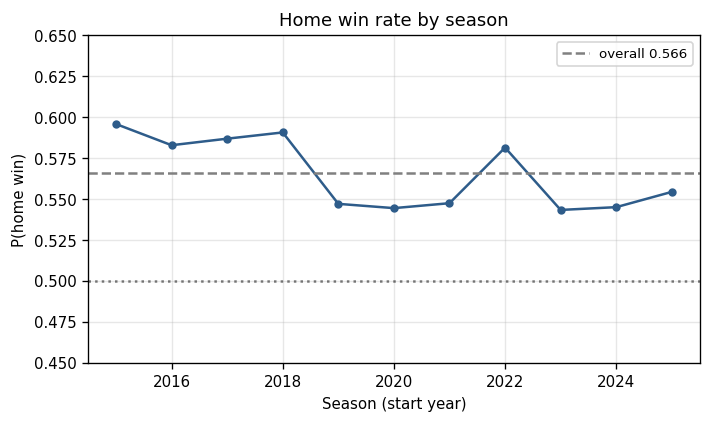

Home win rate by season:
          mean  count
season               
2015    0.5958   1299
2016    0.5829   1309
2017    0.5869   1312
2018    0.5907   1312
2019    0.5471   1137
2020    0.5444   1170
2021    0.5475   1317
2022    0.5814   1314
2023    0.5433   1246
2024    0.5450   1310
2025    0.5544   1315

Correlations with label:
away_win_r10           -0.1732
away_ptdiff_r5         -0.1615
away_fg_pct_r10        -0.1119
rest_advantage         -0.0077
away_pts_allowed_r10    0.0761
home_pts_r10            0.0881
home_fg_pct_r10         0.1224
home_ptdiff_r5          0.1918
home_win_r10            0.2038
form_edge_r10           0.2946
Name: home_win, dtype: float64


In [8]:
# NBA seasons span Oct-Jun, so label a season by its starting year
df['season'] = df['gameDate'].apply(lambda d: d.year if d.month >= 10 else d.year - 1)

# home win rate by season
s = df.groupby('season')['home_win'].agg(['mean','count'])
s = s[s['count'] > 200]

plt.figure(figsize=(6, 3.6))
plt.plot(s.index, s['mean'], marker='o', color=C_HOME, lw=1.5, ms=4)
plt.axhline(df['home_win'].mean(), ls='--', color='gray', label=f"overall {df['home_win'].mean():.3f}")
plt.axhline(0.5, ls=':', color='black', alpha=0.5)
plt.title('Home win rate by season')
plt.xlabel('Season (start year)'); plt.ylabel('P(home win)')
plt.ylim(0.45, 0.65); plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figs/fig_eda.pdf')
plt.show()

# feature correlations with the label (printed, not plotted)
sel = ['form_edge_r10','home_win_r10','away_win_r10','home_ptdiff_r5','away_ptdiff_r5',
       'home_pts_r10','away_pts_allowed_r10','rest_advantage','home_fg_pct_r10','away_fg_pct_r10']
corr = df[sel + ['home_win']].corr()['home_win'].drop('home_win').sort_values()

print('Home win rate by season:'); print(s.round(4))
print(); print('Correlations with label:'); print(corr.round(4))

## save the modeling table


In [9]:
df.drop(columns='season').to_csv('modeling_table.csv', index=False)
print('Saved modeling_table.csv:', df.drop(columns='season').shape)

Saved modeling_table.csv: (14041, 45)
